# **Step 0. Mount Google Drive and Load Dataset**

In [26]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [27]:
import pandas as pd

car_data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Datasets/auto_mpg_binarised.csv')

car_data.head()

,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name,mpg_high
0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu,0
1,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320,0
2,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite,0
3,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst,0
4,8,302.0,140.0,3449.0,10.5,70,1,ford torino,0


In [28]:
car_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   cylinders     398 non-null    int64  
 1   displacement  398 non-null    float64
 2   horsepower    398 non-null    float64
 3   weight        398 non-null    float64
 4   acceleration  398 non-null    float64
 5   model_year    398 non-null    int64  
 6   origin        398 non-null    int64  
 7   car_name      398 non-null    object 
 8   mpg_high      398 non-null    int64  
dtypes: float64(4), int64(4), object(1)
memory usage: 28.1+ KB


In [29]:
#Identify Numeric Columns
#Note: Some times numberic columns are categorical in nature
#example cylinders, model_year, origin
numerical_cols = numeric_cols = ['displacement', 'horsepower', 'weight', 'acceleration']
numerical_cols

['displacement', 'horsepower', 'weight', 'acceleration']

# **1. Histogram**



# 📊 Why do we use a Histogram in EDA?

A **Histogram** is used to understand the distribution of a **numerical feature**. It groups the data into intervals (bins) and shows how many values fall into each interval.

## 🎯 Uses of Histogram

* 📈 **Understand the data distribution**

  * Check whether the data is **Normal**, **Right-skewed**, **Left-skewed**, or **Uniform**.

* 🎯 **Identify where most values are concentrated**

  * Find the range where the majority of observations lie.

* ⚖️ **Detect skewness**

  * Understand whether the data is evenly distributed or biased towards one side.

* 🚨 **Find outliers**

  * Identify unusually high or low values that are far from the rest of the data.

* 📏 **Measure data spread**

  * Check whether the data is closely grouped or widely spread.

## 🌍 Real-World Example

Consider the **Age** column in a dataset.

* 👥 A histogram shows the age ranges (e.g., **20–30**, **30–40**, **40–50**).
* 📊 The height of each bar represents the number of people in that age range.
* ✅ If most people are between **25 and 35**, those bars will be taller.
* 🚨 If only one person is **90 years old**, it may appear as an outlier.

## 💡 Key Takeaway

A Histogram helps answer questions such as:

* ❓ How is the data distributed?
* 📍 Where are most values located?
* ⚖️ Is the data skewed?
* 🚨 Are there any outliers?
* 📏 How spread out is the data?


## **Histogram**

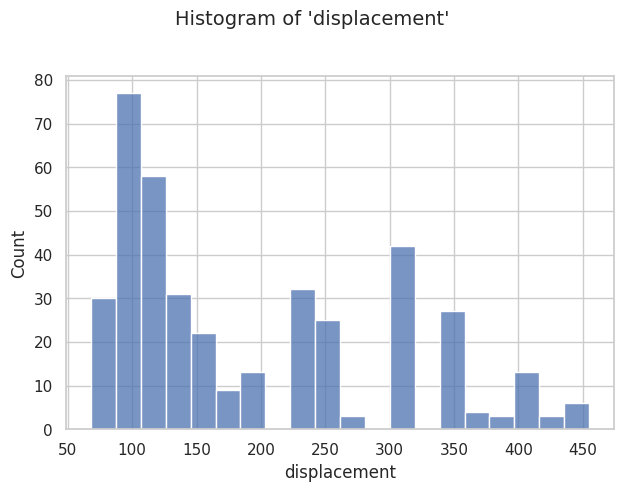

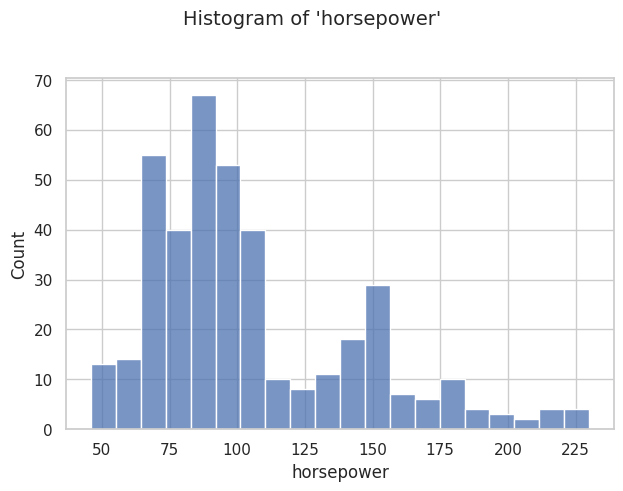

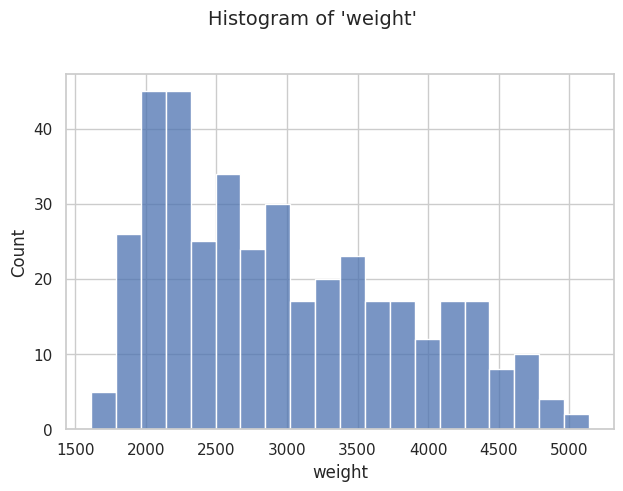

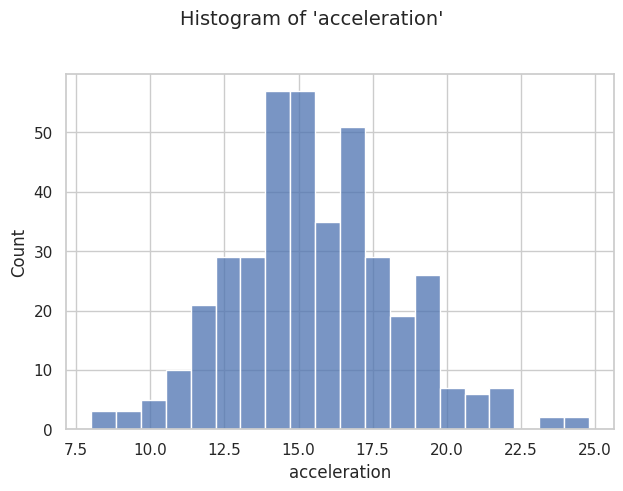

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the global aesthetic style for all subsequent plots to a clean, gridded look
sns.set(style="whitegrid")

# Loop through each numerical column name in the predefined list
for numeric_col in numeric_cols:

    # Draw a histogram on the active axis, dividing the data into 20 bars without a smooth density line (KDE)
    sns.histplot(data=car_data, x=numeric_col, bins=20, kde=False)

    # Place a centered main title above the plot, nudging it upward (y=1.02) so it does not collide with the chart
    plt.suptitle(f"Histogram of '{numeric_col}'", fontsize=14, y=1.02)

    # Automatically adjust subplot padding and labels so nothing gets cut off at the edges
    plt.tight_layout()

    # Render the completed plot to the screen and clear the active figure state for the next loop iteration
    plt.show()

## **Histogram - Class Based Coloring**

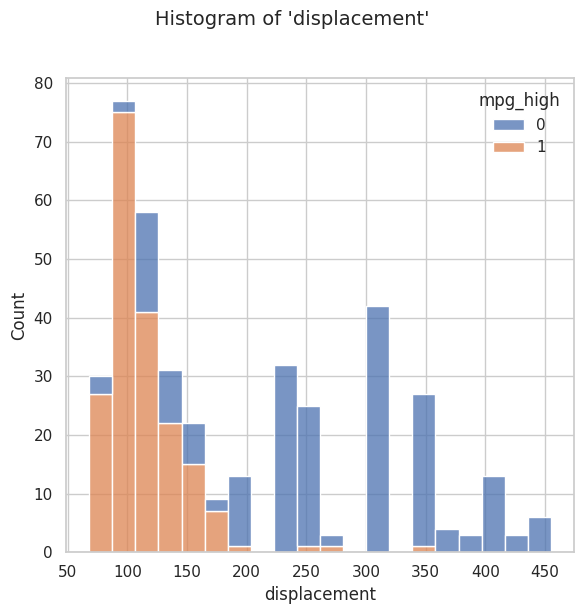

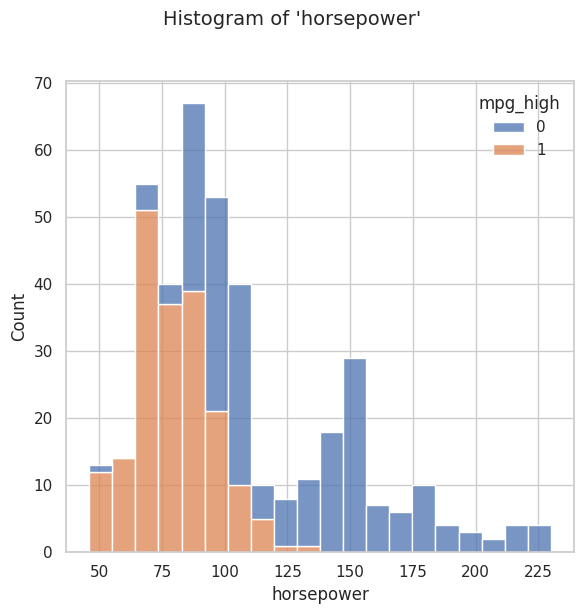

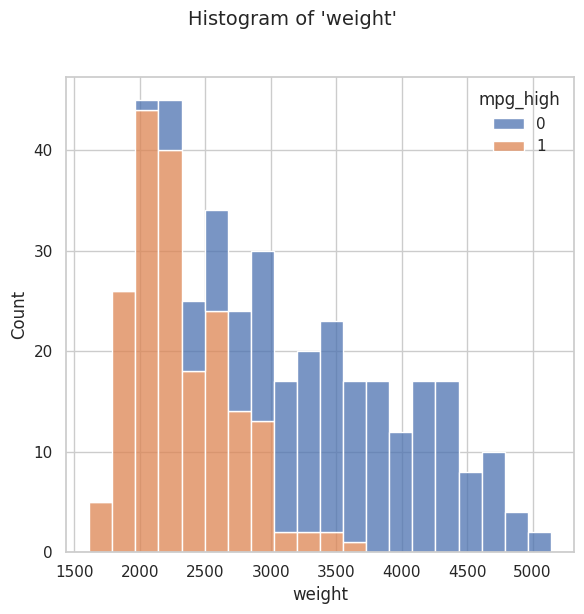

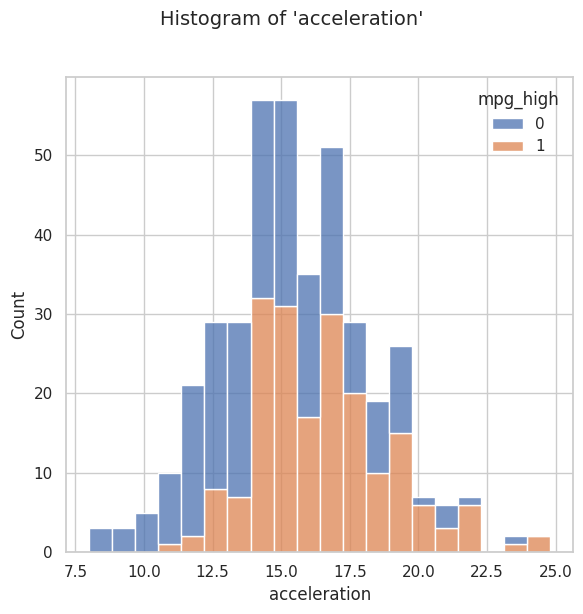

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the global aesthetic style for all subsequent plots to a clean, gridded look
sns.set(style="whitegrid")

# Loop through each numerical column name in the predefined list
for numeric_col in numeric_cols:

    # Create a fresh, independent canvas window for this specific column's plot
    fig, ax = plt.subplots(1, 1, figsize=(6, 6))

    # Draw a stacked histogram where:
    # - data/x: Counts the numeric column values along the horizontal axis
    # - hue: Color-codes the bars based on categories in the 'mpg_high' column (e.g., Low vs High MPG)
    # - multiple='stack': Piles the color groups on top of each other inside the same bar rather than overlapping them
    # - bins/kde: Breaks the data into 20 intervals and turns off the smooth density line
    sns.histplot(data=car_data, x=numeric_col, hue='mpg_high', multiple='stack', bins=20, kde=False)

    # Place a centered main title above the plot, nudging it upward (y=1.02) so it does not collide with the chart
    plt.suptitle(f"Histogram of '{numeric_col}'", fontsize=14, y=1.02)

    # Automatically adjust subplot padding and labels so nothing gets cut off at the edges
    plt.tight_layout()

    # Render the completed plot to the screen and clear the active figure state for the next loop iteration
    plt.show()

# **2. KDE**


# 🌊 Why do we use a KDE Plot in EDA?

A **KDE (Kernel Density Estimation) Plot** is used to understand the distribution of a **numerical feature**. It displays a **smooth density curve**, making it easier to identify the overall shape of the data compared to a histogram.

## 🎯 Uses of KDE Plot

* 📊 **Understand the data distribution**

  * Check whether the data is Normal, Right-skewed, Left-skewed, or Multimodal.

* 🌊 **Visualize a smooth distribution**

  * Shows a smooth curve instead of bars, making patterns easier to understand.

* 📍 **Identify where most values are concentrated**

  * Peaks in the curve indicate where most observations are located.

* ⚖️ **Detect skewness**

  * Understand whether the data is evenly distributed or biased toward one side.

* 🔍 **Compare multiple distributions**

  * Overlay KDE curves of different groups to compare their distributions.

## 🌍 Real-World Example

Consider the **Salary** column in a dataset.

* 🌊 The KDE plot draws a smooth curve representing the salary distribution.
* 📍 The highest peak shows the salary range where most employees belong.
* 📈 A long tail on the right indicates a **Right-Skewed Distribution**.
* 👥 You can compare salary distributions for different departments using different colors.

## 💡 Key Takeaway

A KDE Plot helps answer questions such as:

* ❓ How is the data distributed?
* 🌊 What is the overall shape of the distribution?
* 📍 Where are most values concentrated?
* ⚖️ Is the data skewed?
* 🔍 How do different groups compare?


## **KDE**

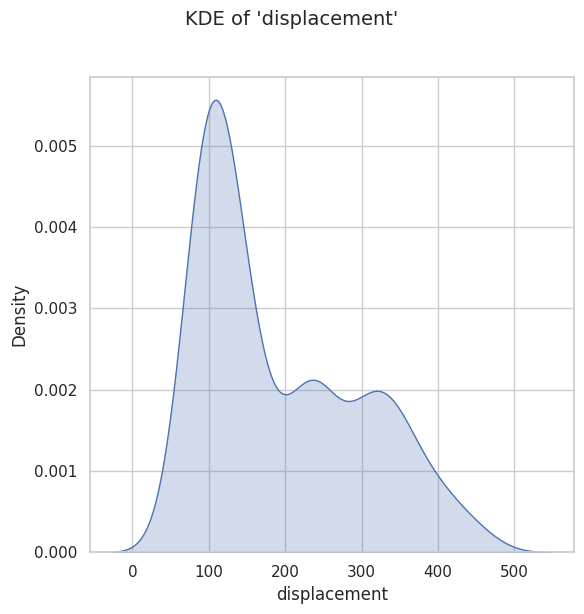

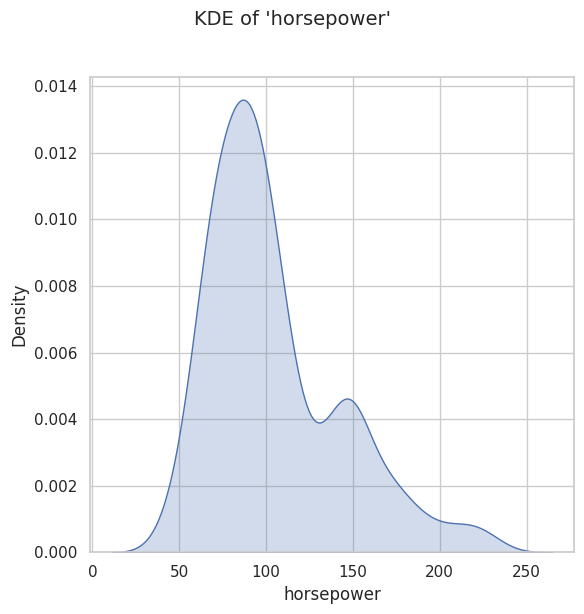

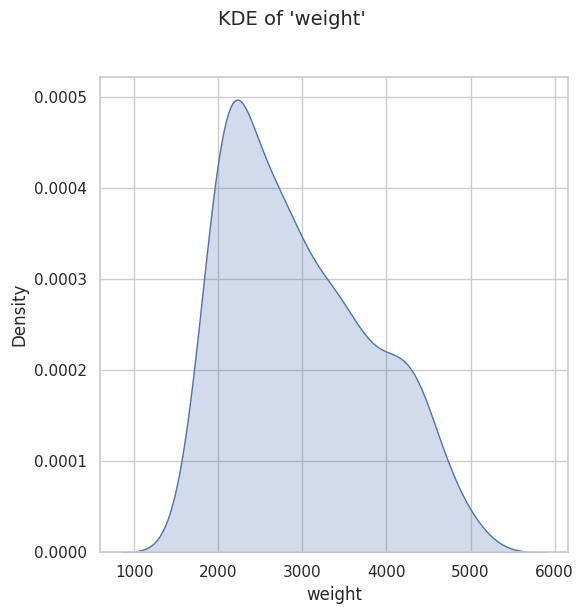

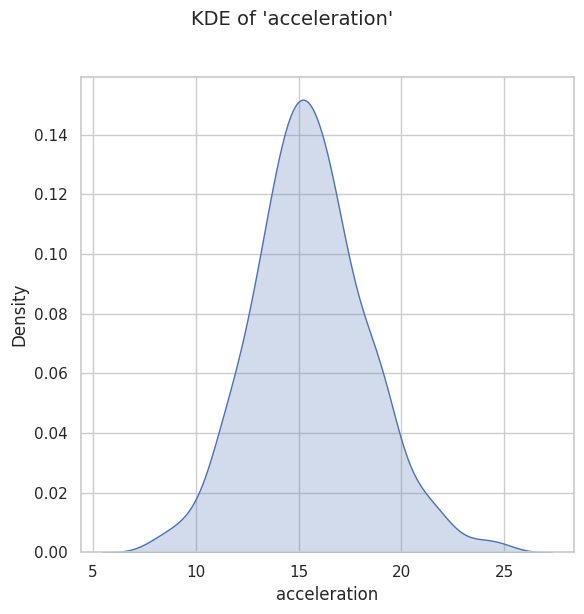

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the global aesthetic style for all subsequent plots to a clean, gridded look
sns.set(style="whitegrid")

# Loop through each numerical column name in the predefined list
for numeric_col in numeric_cols:

    # Create a fresh, independent canvas window for this specific column's plot
    fig, ax = plt.subplots(1, 1, figsize=(6, 6))

    # Draw a smooth Kernel Density Estimate (KDE) plot where:
    # - data/x: Plots the probability density of the numerical column along the horizontal axis
    # - fill=True: Shades the area underneath the curve to make the distribution easier to visualize
    # - common_norm=False: Normalizes each group independently so that a small category's shape
    #   isn't washed out or shrunk down by a much larger category in the dataset
    sns.kdeplot(data=car_data, x=numeric_col, fill=True, common_norm=False)

    # Place a centered main title above the plot, nudging it upward (y=1.02) so it does not collide with the chart
    plt.suptitle(f"KDE of '{numeric_col}'", fontsize=14, y=1.02)

    # Automatically adjust subplot padding and labels so nothing gets cut off at the edges
    plt.tight_layout()

    # Render the completed plot to the screen and clear the active figure state for the next loop iteration
    plt.show()

## **KDE - Class Based Coloring**

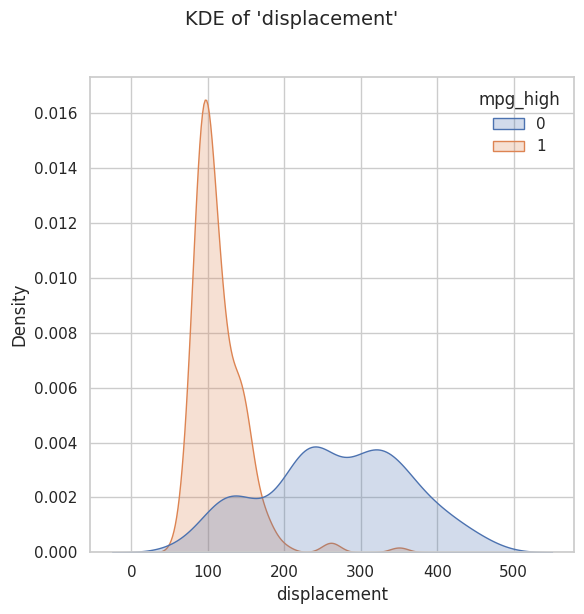

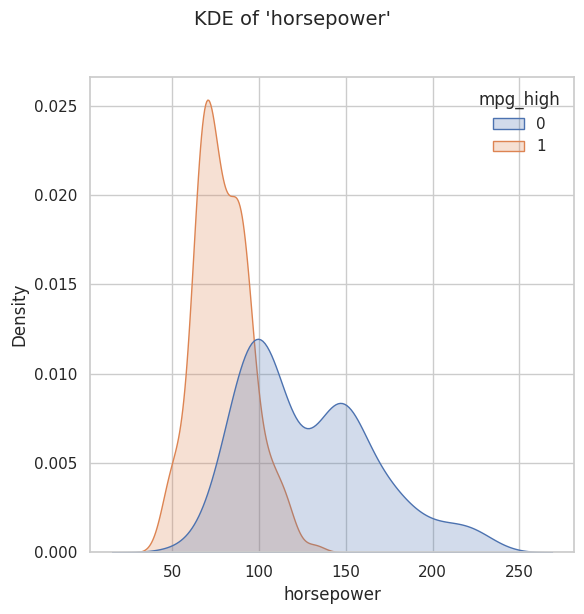

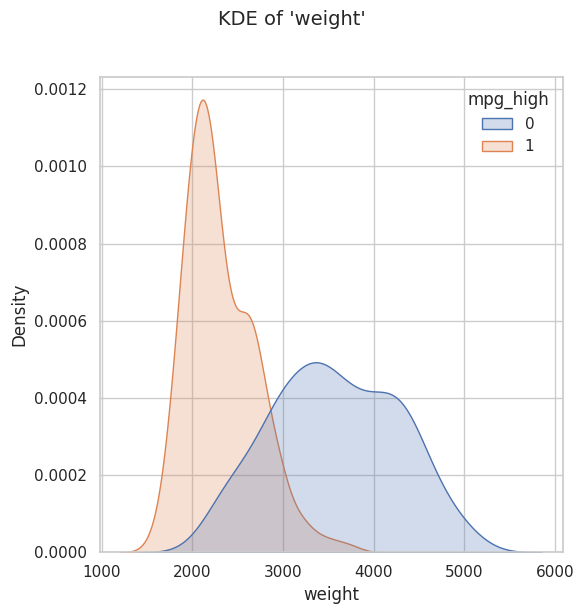

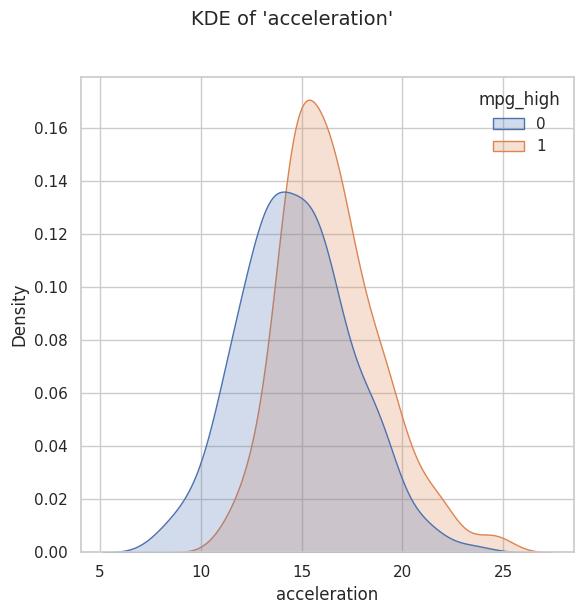

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the global aesthetic style for all subsequent plots to a clean, gridded look
sns.set(style="whitegrid")

# Loop through each numerical column name in the predefined list
for numeric_col in numeric_cols:

    # Create a fresh, independent canvas window for this specific column's plot
    fig, ax = plt.subplots(1, 1, figsize=(6, 6))

    # Draw a grouped, smooth Kernel Density Estimate (KDE) plot where:
    # - data/x: Plots the probability density of the numerical column along the horizontal axis
    # - hue: Splits the density distributions into separate, color-coded curves based on 'mpg_high'
    # - fill=True: Shades the areas underneath both curves to clearly highlight the visual spread
    # - common_norm=False: Scales each curve independently relative to its own group size, ensuring
    #   smaller categories aren't visually minimized or flattened by larger ones
    sns.kdeplot(data=car_data, x=numeric_col, hue='mpg_high', fill=True, common_norm=False)

    # Place a centered main title above the plot, nudging it upward (y=1.02) so it does not collide with the chart
    plt.suptitle(f"KDE of '{numeric_col}'", fontsize=14, y=1.02)

    # Automatically adjust subplot padding and labels so nothing gets cut off at the edges
    plt.tight_layout()

    # Render the completed plot to the screen and clear the active figure state for the next loop iteration
    plt.show()

# **3. Scatter Plot**


# 📍 Why do we use a Scatter Plot in EDA?

A **Scatter Plot** is used to understand the relationship between **two numerical features**. Each point on the graph represents one observation in the dataset.

## 🎯 Uses of Scatter Plot

* 🔗 **Understand the relationship between two variables**

  * Check whether two numerical features are related.

* 📈 **Identify positive or negative correlation**

  * See whether one variable increases or decreases as the other changes.

* 🚨 **Detect outliers**

  * Find data points that are far away from the rest of the observations.

* 📊 **Identify clusters or groups**

  * Check whether the data naturally forms different groups.

* 📉 **Identify patterns or trends**

  * Understand whether the relationship is Linear, Non-linear, or if there is no relationship.

## 🌍 Real-World Example

Consider a dataset with **Hours Studied** and **Exam Score**.

* 📚 Each point represents one student.
* 📈 If students who study more generally score higher, the points will show an upward trend (**Positive Correlation**).
* 📉 If one variable increases while the other decreases, it shows a **Negative Correlation**.
* 🚫 If the points are scattered randomly, there may be **No Correlation**.
* 🚨 A student who studied very little but scored very high may appear as an **Outlier**.

## 💡 Key Takeaway

A Scatter Plot helps answer questions such as:

* ❓ Is there a relationship between two numerical features?
* 📈 Is the relationship positive or negative?
* 📉 Is the relationship linear or non-linear?
* 🚨 Are there any outliers?
* 👥 Does the data form clusters or groups?


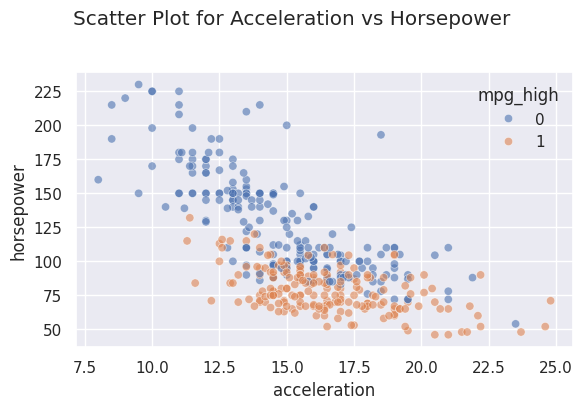

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a fresh canvas window with a width of 6 inches and height of 4 inches
plt.figure(figsize=(6, 4))

# Draw the scatter plot where:
# - x & y: Plot engine size ('Acceleration') against engine output ('horsepower')
# - hue: Color-codes each point based on the 'mpg_high' category
# - alpha=0.6: Makes points 60% opaque (40% transparent) to reveal high-density overlapping areas
sns.scatterplot(
    data=car_data,
    x='acceleration',
    y='horsepower',
    hue='mpg_high',
    alpha=0.6
)

# Place a centered main title above the plot, nudging it up slightly so it doesn't overlap the top axis
plt.suptitle("Scatter Plot for Acceleration vs Horsepower", y=1.02)

# Automatically adjust the margins and padding so no axis text or labels get clipped
plt.tight_layout()

# Render the final visualization onto the screen and clear the active figure state
plt.show()

# **4. Pair Plot**


# 🔄 Why do we use a Pair Plot in EDA?

A **Pair Plot** is used to understand the relationship between **multiple numerical features** in a dataset. It combines **scatter plots** and **histograms (or KDE plots)** into a single visualization.

## 🎯 Uses of Pair Plot

* 🔗 **Understand relationships between multiple numerical features**

  * Compare every numerical feature with every other numerical feature.

* 📈 **Identify correlation**

  * Check whether two features have a positive, negative, or no relationship.

* 📊 **Understand the distribution of each feature**

  * The diagonal plots show how each numerical feature is distributed.

* 🚨 **Detect outliers**

  * Identify unusual data points that are far from the rest.

* 👥 **Identify clusters or groups**

  * Check whether the data forms natural groups, especially when using the **`hue`** parameter.

## 🌍 Real-World Example

Consider a dataset with **Height**, **Weight**, and **Age**.

* 📍 Each scatter plot compares two features (e.g., Height vs Weight).
* 📊 The diagonal plots show the distribution of each feature.
* 📈 You can easily see whether taller people tend to weigh more.
* 👥 Using the **`hue`** parameter (e.g., Male/Female) helps visualize different groups.
* 🚨 Any unusual observations may appear as outliers.

## 💡 Key Takeaway

A Pair Plot helps answer questions such as:

* ❓ How are multiple numerical features related?
* 📈 Which features are strongly correlated?
* 📊 What is the distribution of each feature?
* 🚨 Are there any outliers?
* 👥 Does the data form different groups or clusters?


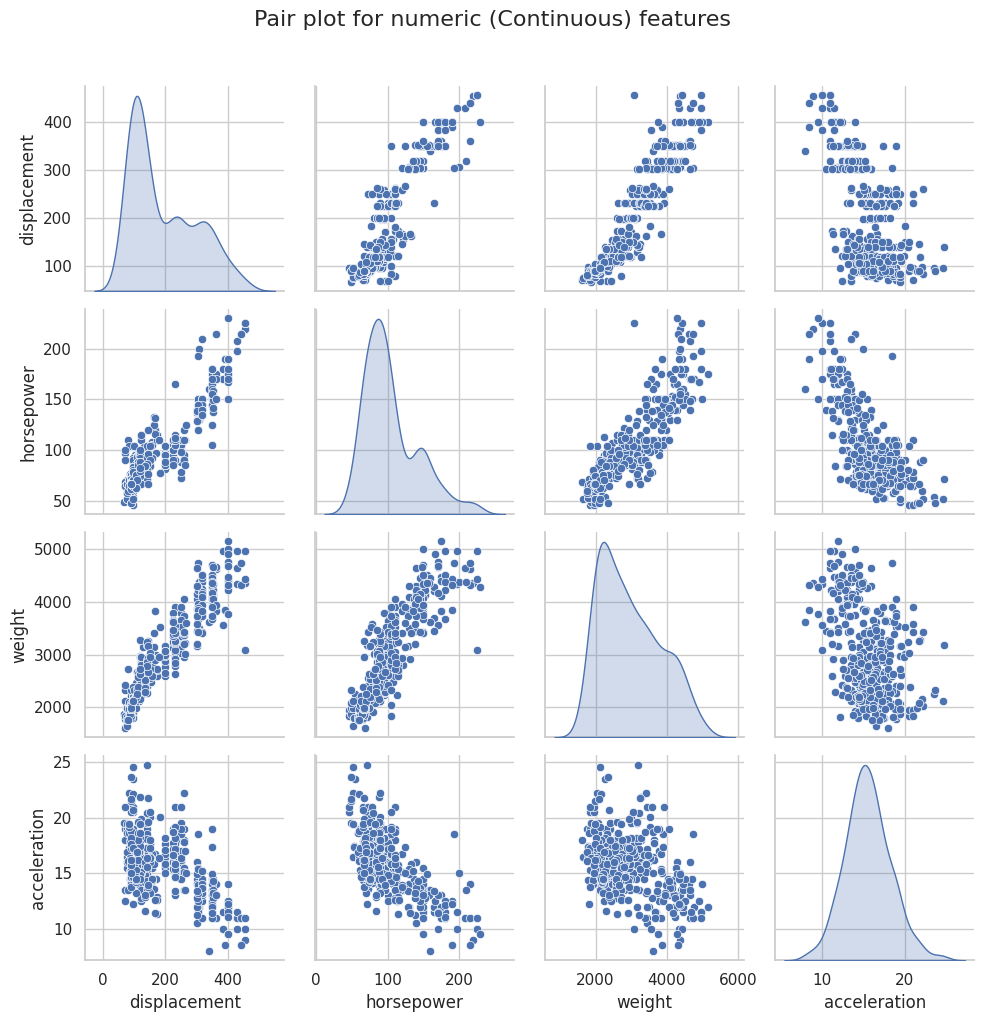

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the global background theme to a clean white grid for all subplots
sns.set(style="whitegrid")

# Draw a grid of pairwise plots where:
# - data: The source DataFrame containing the car dataset
# - vars: Evaluates only the columns listed in 'numeric_cols' to keep the grid relevant
# - diag_kind='kde': Places smooth Kernel Density Estimate curves along the diagonal instead of histograms
sns.pairplot(data=car_data, vars=numeric_cols, diag_kind='kde')

# Place a centered main title above the multi-plot grid
# Note: Pairplot grids are naturally tall; setting y=1.02 positions it perfectly above the top row
plt.suptitle("Pair plot for numeric (Continuous) features", fontsize=16, y=1.02)

# Automatically adjust the spacing between subplots so labels and axes don't overlap
plt.tight_layout()

# Render the final matrix grid onto the screen
plt.show()